In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nchains"]))

In [3]:
samples = np.load(f"../../../../output/age_depth_unified/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_unified/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_unified/bias_values_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_unified/resampsamp_{config_str}.npy")

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [5]:
print(energy_values)

[[ 829.84106602  547.45076821  320.28372832 ...   91.43313796
    91.31408431   93.10421268]
 [2011.5419857  1234.19051055  835.36821678 ...  145.0947834
   145.31552025  146.44452229]
 [ 881.94243577  849.94691487  806.32348413 ...  109.48652774
   108.44417471  106.35645897]
 [1055.47362014  673.38319023  481.75259124 ...   75.37670069
    76.24987025   75.48247218]]


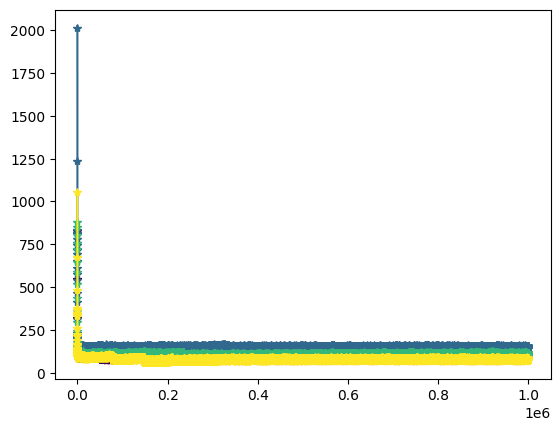

In [6]:
plt.figure()
for i in range(config["nchains"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
    plt.plot(energy_values[i,:], '*', color = colors[i])
plt.show()

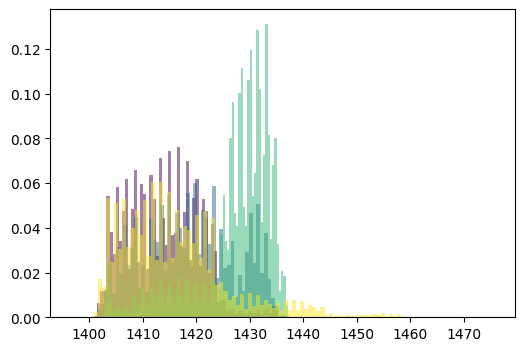

In [7]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nchains"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [8]:
resampled_samples = resampled_samples[:,::1000,:]

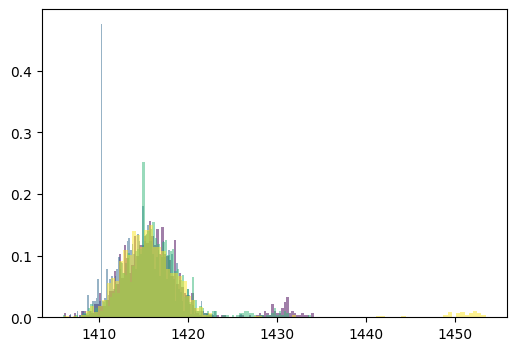

In [9]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nchains"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

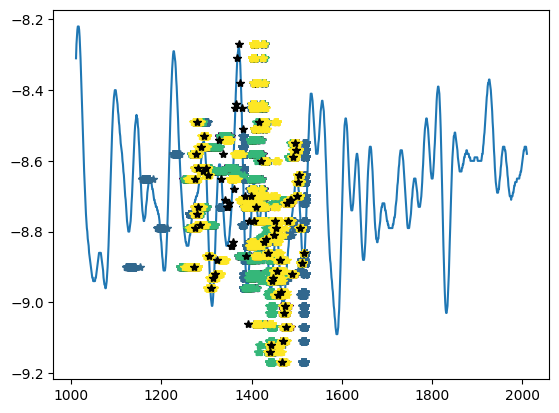

In [10]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nchains"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [11]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]   7.61   4.32    0.01    11.53       2.10     1.16      7.16     29.23   
x[1]  12.79   9.58    0.15    28.49       4.72     2.37      4.90     28.47   
x[2]   5.01   3.46    0.09    10.77       1.45     0.06      6.38    133.14   
x[3]  15.34  13.72    0.08    38.93       6.77     3.59      4.97     29.34   
x[4]  11.28   2.48    7.32    16.03       0.04     0.05   3555.95   3607.12   
x[5]   5.40   2.39    1.69     8.72       0.27     0.10     66.34    271.52   
x[6]   3.99   4.15    0.06    11.28       1.99     1.06      6.69     29.50   
x[7]  11.95  18.95    0.00    46.03       9.42     5.45      5.47     30.45   
x[8]  29.04  22.20    0.29    58.79      10.89     2.05      5.22     27.99   
x[9]  47.64  52.78    1.56   139.65      26.06    14.54      5.75     30.77   

      r_hat  
x[0]   1.53  
x[1]   2.41  
x[2]   1.67  
x[3]   2.34  
x[4]   1.01  
x[5]   1.04  
x[6]   1.61  
x[7]   1.97  
x[8]

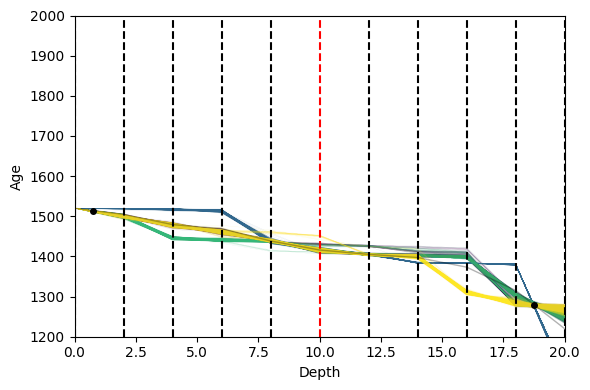

In [12]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nchains"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()